In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd

# Load the uploaded dataset
file_path = '/content/gdrive/MyDrive/reviews/Womens Clothing E-Commerce Reviews.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
# Check null value
data.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


In [ ]:
# Step 1: Drop rows with missing values in critical columns (Review Text and Rating)
data_cleaned = data.dropna(subset=['Review Text', 'Rating'])

# Step 2: Clean the Review Text column (lowercasing, removing special characters)
import re

def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters and numbers
    return text

data_cleaned['Cleaned Review Text'] = data_cleaned['Review Text'].apply(clean_text)

data_cleaned.head()


<ipython-input-4-faed543868dd>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Cleaned Review Text'] = data_cleaned['Review Text'].apply(clean_text)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Cleaned Review Text
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfo...
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress its sooo pretty i happened t...
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit its fun flirty ...
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...


In [ ]:
data_cleaned.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,2966
Review Text,0
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,13
Department Name,13


In [ ]:
data_cleaned["Rating"].value_counts()

,count
Rating,
5,12540
4,4908
3,2823
2,1549
1,821


<ipython-input-6-f086c38129b1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Rating",data=data_cleaned,palette="cool")


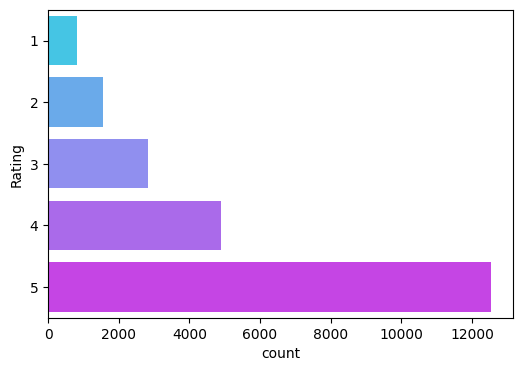

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

%matplotlib inline

plt.figure(figsize=(6,4))
sns.countplot(y="Rating",data=data_cleaned,palette="cool")
plt.show()

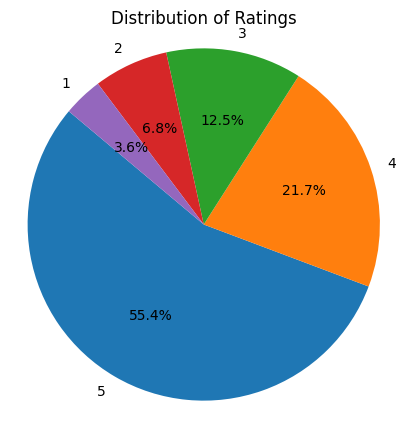

In [ ]:
rating_counts = data_cleaned["Rating"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Ratings')
plt.axis('equal')
plt.show()

In [ ]:
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already available
nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords from text
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Apply the function to the Cleaned Review Text column
data_cleaned['Cleaned Review Text'] = data_cleaned['Cleaned Review Text'].apply(remove_stopwords)

data_cleaned.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
<ipython-input-5-67cba4228e64>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Cleaned Review Text'] = data_cleaned['Cleaned Review Text'].apply(remove_stopwords)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Cleaned Review Text
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky sexy comfortable
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love dress sooo pretty happened find store im ...
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,high hopes dress really wanted work initially ...
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,love love love jumpsuit fun flirty fabulous ev...
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,shirt flattering due adjustable front tie perf...


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming the dataset is already cleaned and available as `data_cleaned`
# First, split data into train+validation and test sets
train_val, test = train_test_split(data_cleaned, test_size=0.15, random_state=42)

# Then split train+validation into train and validation sets
train, val = train_test_split(train_val, test_size=0.1765, random_state=42)  # 0.1765 to maintain the 15% validation size

# Display the sizes of each split
train_size = len(train)
val_size = len(val)
test_size = len(test)

train_size, val_size, test_size


(15847, 3397, 3397)

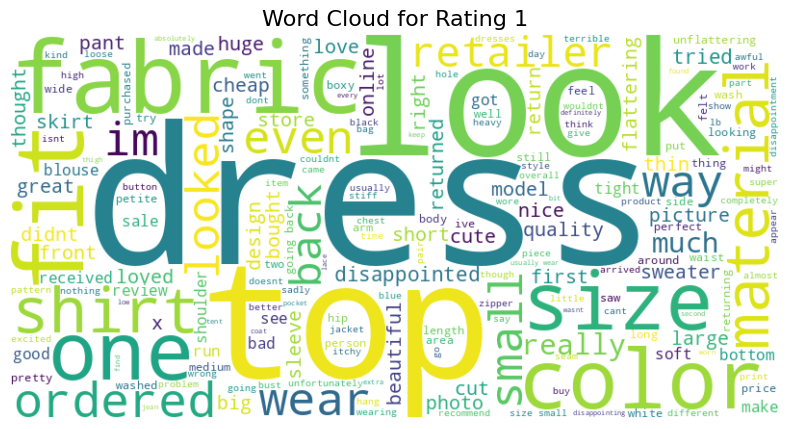

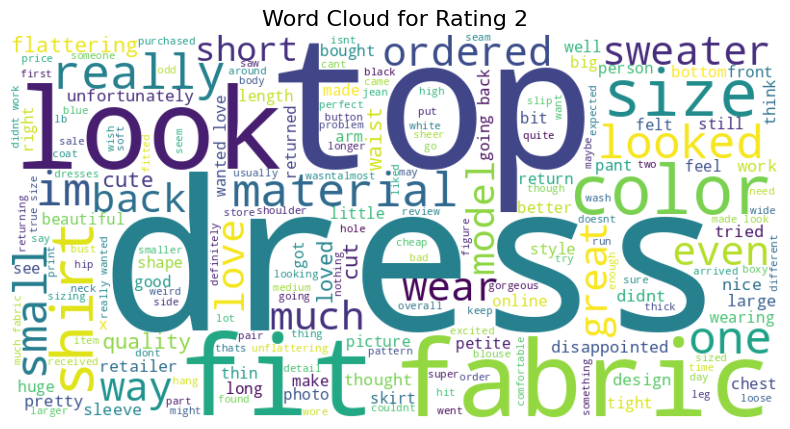

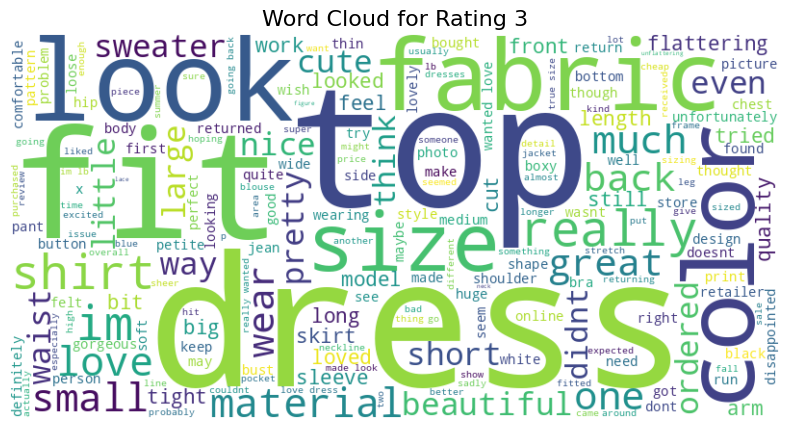

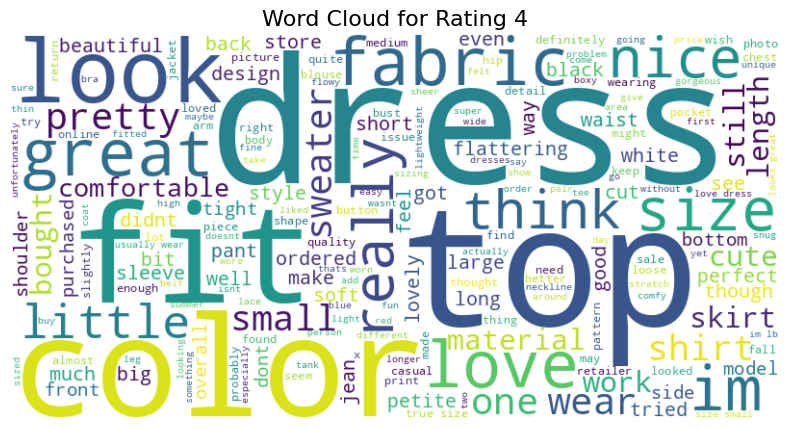

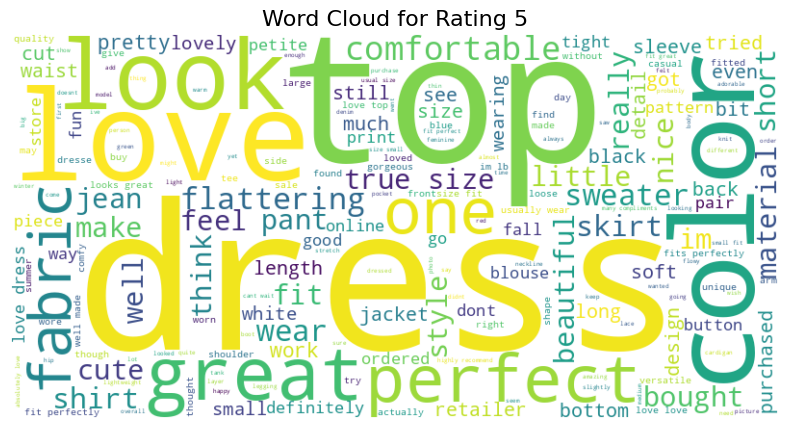

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate a word cloud for a specific rating
def generate_wordcloud(data, rating):
    text = ' '.join(data[data['Rating'] == rating]['Cleaned Review Text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.title(f"Word Cloud for Rating {rating}", fontsize=16)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

# Generate word clouds for each rating (1 to 5)
for rating in range(1, 6):
    generate_wordcloud(train, rating)


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare Glove
embeddings_index = {}
with open("/content/gdrive/MyDrive/Glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Processing the embedding text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train['Cleaned Review Text'])
sequences = tokenizer.texts_to_sequences(train['Cleaned Review Text'])

word_index = tokenizer.word_index
max_len = 100  # حداکثر طول دنباله‌ها
data = pad_sequences(sequences, maxlen=max_len)


In [ ]:
print(f"Input data shape: {data.shape}")


Input data shape: (15847, 100)


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the data

# Process validation data similarly to the training data
sequences_val = tokenizer.texts_to_sequences(val['Cleaned Review Text'])
X_val = pad_sequences(sequences_val, maxlen=max_len)
y_val = val['Rating'].values

# 2. Prepare GloVe embeddings
embeddings_index = {}
with open("/content/gdrive/MyDrive/Glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# 3. Convert text data to sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train['Cleaned Review Text'])
sequences = tokenizer.texts_to_sequences(train['Cleaned Review Text'])

word_index = tokenizer.word_index
max_len = 100  # Maximum sequence length
data = pad_sequences(sequences, maxlen=max_len)

# 4. Prepare embedding matrix
embedding_dim = 100
num_words = len(word_index) + 1
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# 5. Build the LSTM model
input_layer = Input(shape=(max_len,), dtype='int32')
embedding_layer = Embedding(input_dim=num_words,
                            output_dim=embedding_dim,
                            weights=[embedding_matrix],
                            input_length=max_len,
                            trainable=False)(input_layer)
lstm1 = LSTM(128, return_sequences=True)(embedding_layer)
dropout1 = Dropout(0.2)(lstm1)
lstm2 = LSTM(64, return_sequences=False)(dropout1)
dropout2 = Dropout(0.2)(lstm2)
output_layer = Dense(1, activation='linear')(dropout2)

model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Display the model structure
model.summary()

# 6. Train the model
y = train['Rating'].values
model.fit(data, y, batch_size=32, epochs=50, validation_data=(X_val, y_val))

# 7. Make predictions on validation data
y_pred_val = model.predict(X_val)

# 8. Evaluate performance on validation data
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print(f"Validation Mean Absolute Error (MAE): {mae_val}")
print(f"Validation Root Mean Squared Error (RMSE): {rmse_val}")


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 100, 100)            │       1,503,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_12 (LSTM)                       │ (None, 100, 128)            │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 100, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,670,021 (6.37 MB)

 Trainable params: 166,721 (651.25 KB)

 Non-trainable params: 1,503,300 (5.73 MB)

Epoch 1/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 144s 282ms/step - loss: 2.0763 - mae: 1.0738 - val_loss: 0.8244 - val_mae: 0.7438
Epoch 2/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 128s 258ms/step - loss: 0.8644 - mae: 0.7109 - val_loss: 0.7577 - val_mae: 0.6818
Epoch 3/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 147s 267ms/step - loss: 0.7515 - mae: 0.6594 - val_loss: 0.6425 - val_mae: 0.5996
Epoch 4/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 141s 265ms/step - loss: 0.6929 - mae: 0.6312 - val_loss: 0.6183 - val_mae: 0.6089
Epoch 5/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 131s 264ms/step - loss: 0.6543 - mae: 0.6145 - val_loss: 0.6087 - val_mae: 0.5970
Epoch 6/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 130s 262ms/step - loss: 0.5760 - mae: 0.5771 - val_loss: 0.5905 - val_mae: 0.5779
Epoch 7/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 146s 271ms/step - loss: 0.5495 - mae: 0.5590 - val_loss: 0.5988 - val_mae: 0.5968
Epoch 8/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 139s 266ms/step - loss: 0.5104 - mae: 0.5428 - val_loss: 0.5748 - val_mae: 0.5601
Epoch 9/50
496/496 ━━━━━

107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step
Test Mean Absolute Error (MAE): 0.5434132218360901
Test Root Mean Squared Error (RMSE): 0.8372115649117594


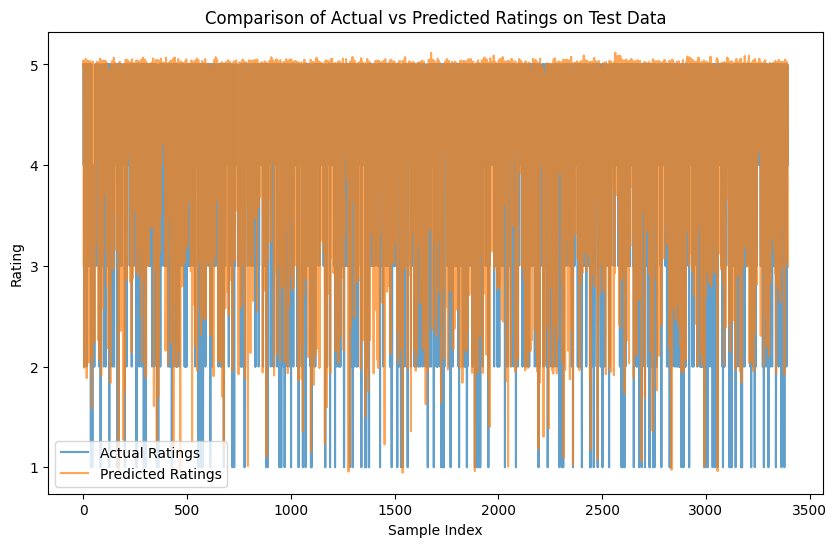

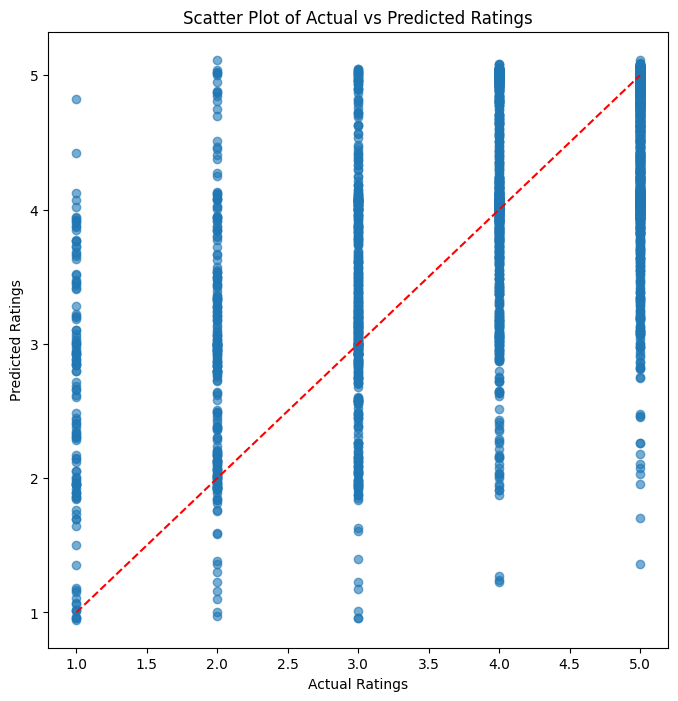

In [ ]:
import matplotlib.pyplot as plt

# 1. Preprocessing the test data
sequences_test = tokenizer.texts_to_sequences(test['Cleaned Review Text'])
X_test = pad_sequences(sequences_test, maxlen=max_len)
y_test = test['Rating'].values

# 2. Predicting on the test data
y_pred_test = model.predict(X_test)

# 3. Evaluating performance on the test data
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Test Mean Absolute Error (MAE): {mae_test}")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test}")

# 1. Plotting a comparison between actual and predicted ratings
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Ratings', alpha=0.7)  # Plot actual ratings
plt.plot(y_pred_test, label='Predicted Ratings', alpha=0.7)  # Plot predicted ratings
plt.title('Comparison of Actual vs Predicted Ratings on Test Data')  # Title of the plot
plt.xlabel('Sample Index')  # X-axis label
plt.ylabel('Rating')  # Y-axis label
plt.legend()  # Add legend to distinguish between actual and predicted
plt.show()

# 2. Plotting a scatter plot for more detailed comparison
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6)  # Scatter plot of actual vs predicted ratings
plt.title('Scatter Plot of Actual vs Predicted Ratings')  # Title of the scatter plot
plt.xlabel('Actual Ratings')  # X-axis label
plt.ylabel('Predicted Ratings')  # Y-axis label
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Reference line (y=x)
plt.show()




In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Loading the data

# Preprocessing validation data, similar to training data
sequences_val = tokenizer.texts_to_sequences(val['Cleaned Review Text'])
X_val = pad_sequences(sequences_val, maxlen=max_len)
y_val = val['Rating'].values

# 2. Preparing Glove embeddings
embeddings_index = {}
with open("/content/gdrive/MyDrive/Glove/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]  # First token is the word
        coefs = np.asarray(values[1:], dtype='float32')  # Remaining tokens are the vector
        embeddings_index[word] = coefs

# 3. Converting text to sequences
tokenizer = Tokenizer()  # Initialize the tokenizer
tokenizer.fit_on_texts(train['Cleaned Review Text'])  # Fit the tokenizer on training text
sequences = tokenizer.texts_to_sequences(train['Cleaned Review Text'])  # Convert text to sequences

word_index = tokenizer.word_index  # Dictionary mapping words to their indices
max_len = 100  # Maximum sequence length
data = pad_sequences(sequences, maxlen=max_len)  # Pad sequences to ensure uniform length

# 4. Preparing the embedding matrix
embedding_dim = 100  # Dimension of Glove vectors
num_words = len(word_index) + 1  # Number of unique words in the tokenizer
embedding_matrix = np.zeros((num_words, embedding_dim))  # Initialize embedding matrix with zeros
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)  # Get the Glove vector for the word
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector  # Assign the Glove vector to the embedding matrix

# 5. Building the BiLSTM model
input_layer = Input(shape=(max_len,), dtype='int32')  # Input layer for sequences
embedding_layer = Embedding(input_dim=num_words,
                            output_dim=embedding_dim,
                            weights=[embedding_matrix],
                            input_length=max_len,
                            trainable=False)(input_layer)  # Embedding layer with pre-trained weights

# First BiLSTM layer
bilstm1 = Bidirectional(LSTM(128, return_sequences=True))(embedding_layer)  # BiLSTM with 128 units
dropout1 = Dropout(0.2)(bilstm1)  # Dropout for regularization

# Second BiLSTM layer
bilstm2 = Bidirectional(LSTM(64, return_sequences=False))(dropout1)  # BiLSTM with 64 units
dropout2 = Dropout(0.2)(bilstm2)  # Dropout for regularization

# Dense layer for the output
output_layer = Dense(1, activation='linear')(dropout2)  # Linear activation for regression

model = Model(inputs=input_layer, outputs=output_layer)  # Create the model

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])  # Use MSE loss and MAE metric

# Display model structure
model.summary()

# 6. Training the model
y = train['Rating'].values  # Extract ratings as target variable
model.fit(data, y, batch_size=32, epochs=50, validation_data=(X_val, y_val))  # Train the model

# 7. Making predictions on the validation data
y_pred_val = model.predict(X_val)

# 8. Evaluating performance on validation data
mae_val = mean_absolute_error(y_val, y_pred_val)  # Calculate MAE
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))  # Calculate RMSE

print(f"Validation Mean Absolute Error (MAE): {mae_val}")
print(f"Validation Root Mean Squared Error (RMSE): {rmse_val}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 100, 100)            │       1,503,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 100, 256)            │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,902,277 (7.26 MB)

 Trainable params: 398,977 (1.52 MB)

 Non-trainable params: 1,503,300 (5.73 MB)

Epoch 1/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 265s 521ms/step - loss: 2.0899 - mae: 1.0788 - val_loss: 0.8598 - val_mae: 0.7391
Epoch 2/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 266s 529ms/step - loss: 0.8957 - mae: 0.7245 - val_loss: 0.7238 - val_mae: 0.6365
Epoch 3/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 262s 529ms/step - loss: 0.7402 - mae: 0.6540 - val_loss: 0.6446 - val_mae: 0.6164
Epoch 4/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 261s 527ms/step - loss: 0.6519 - mae: 0.6073 - val_loss: 0.6180 - val_mae: 0.6118
Epoch 5/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 257s 518ms/step - loss: 0.6048 - mae: 0.5848 - val_loss: 0.6037 - val_mae: 0.5800
Epoch 6/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 265s 524ms/step - loss: 0.5569 - mae: 0.5636 - val_loss: 0.6131 - val_mae: 0.5769
Epoch 7/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 266s 532ms/step - loss: 0.5135 - mae: 0.5380 - val_loss: 0.6002 - val_mae: 0.5610
Epoch 8/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 319s 525ms/step - loss: 0.4711 - mae: 0.5179 - val_loss: 0.6023 - val_mae: 0.5329
Epoch 9/50
496/496 ━━━━━

107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step
Test Mean Absolute Error (MAE): 0.5395618677139282
Test Root Mean Squared Error (RMSE): 0.8192987626818702


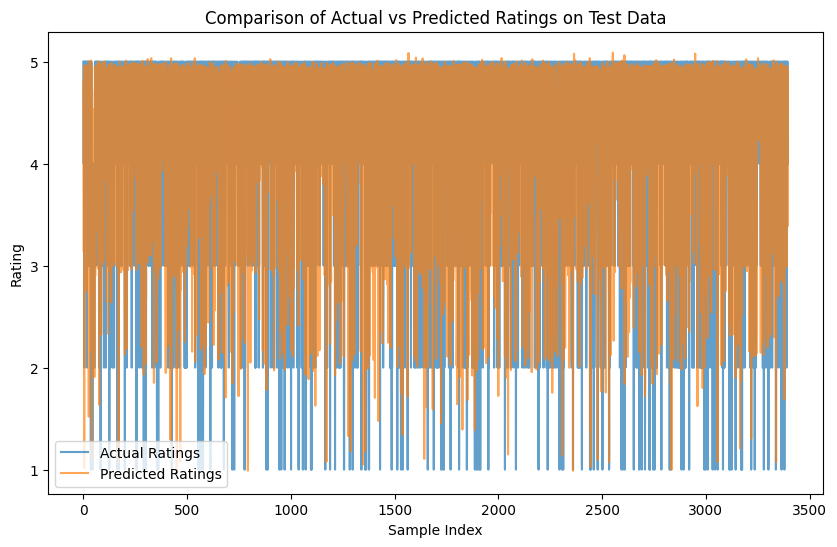

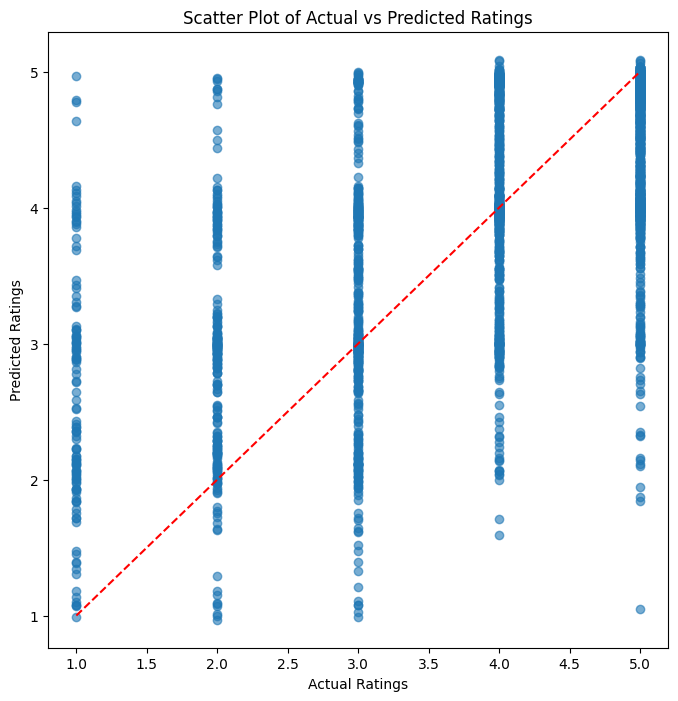

In [ ]:
import matplotlib.pyplot as plt

# فرض کنید داده‌های تست شامل:
# test['Cleaned Review Text']: متن‌های تست پیش‌پردازش‌شده
# test['Rating']: امتیازهای واقعی داده‌های تست

# 1. پیش‌پردازش داده‌های تست
sequences_test = tokenizer.texts_to_sequences(test['Cleaned Review Text'])
X_test = pad_sequences(sequences_test, maxlen=max_len)
y_test = test['Rating'].values

# 2. پیش‌بینی روی داده‌های تست
y_pred_test = model.predict(X_test)

# 3. ارزیابی عملکرد روی داده‌های تست
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"Test Mean Absolute Error (MAE): {mae_test}")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test}")

# 1. رسم نمودار مقایسه‌ای بین مقادیر واقعی و پیش‌بینی‌شده
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Ratings', alpha=0.7)
plt.plot(y_pred_test, label='Predicted Ratings', alpha=0.7)
plt.title('Comparison of Actual vs Predicted Ratings on Test Data')
plt.xlabel('Sample Index')
plt.ylabel('Rating')
plt.legend()
plt.show()

# 2.  رسم نمودار پراکندگی
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.title('Scatter Plot of Actual vs Predicted Ratings')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # خط y=x برای مرجع
plt.show()